# Credit Card Fraud Detection Using Scikit-learn

## Project objective
Build a binary classification model that identifies fraudulent credit-card transactions.

- **Dataset:** [Credit Card Fraud Detection on Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)
- **Class 0:** Legitimate transaction
- **Class 1:** Fraudulent transaction
- **Main challenge:** Fraud cases are extremely rare, so accuracy alone is misleading.
- **Main evaluation metrics:** Precision, Recall, F1-score, ROC-AUC, Average Precision, and the Confusion Matrix.

This notebook compares a baseline classifier, Logistic Regression, and Random Forest using `scikit-learn`.

## Stage 1: Import libraries

In [102]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


In [103]:
RANDOM_STATE = 42
plt.style.use('ggplot')
pd.set_option('display.max_columns', 40)

## Stage 2: Load and explore the data

Upload `creditcard.csv` to the Colab Files panel before running the next cell.

In [104]:
df = pd.read_csv('/content/creditcard.csv')

print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
print('Column names:', list(df.columns))
df.head()

Rows: 284807
Columns: 31
Column names: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [106]:
df[['Time', 'Amount', 'Class']].describe()

,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


### Data quality checks

Exact duplicate rows are removed before splitting the data. This reduces the risk of the same observation appearing in both training and test sets.

In [107]:
print('Missing values:', int(df.isna().sum().sum()))
print('Duplicate rows:', int(df.duplicated().sum()))

if df.isna().sum().sum() > 0:
    raise ValueError('Missing values were found. Add an appropriate imputation step before training.')

df = df.drop_duplicates().reset_index(drop=True)
print('Rows after removing duplicates:', len(df))

Missing values: 0
Duplicate rows: 1081
Rows after removing duplicates: 283726


### Target-class distribution

In [108]:
class_summary = pd.DataFrame({
    'Count': df['Class'].value_counts().sort_index(),
    'Percentage': df['Class'].value_counts(normalize=True).sort_index() * 100,
})
class_summary.index = ['Legitimate (0)', 'Fraud (1)']
class_summary

,Count,Percentage
Legitimate (0),283253,99.83329
Fraud (1),473,0.16671


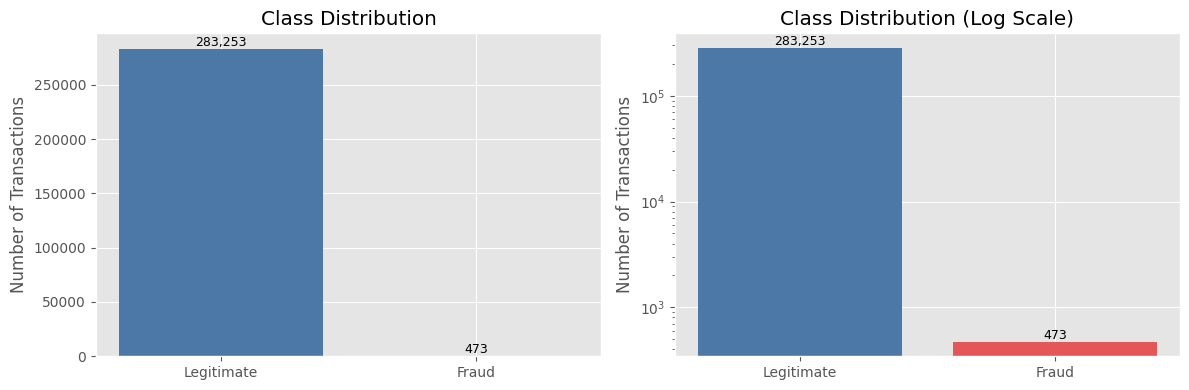

In [109]:
class_counts = df['Class'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Legitimate', 'Fraud'], class_counts.values, color=['#4C78A8', '#E45756'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Number of Transactions')

axes[1].bar(['Legitimate', 'Fraud'], class_counts.values, color=['#4C78A8', '#E45756'])
axes[1].set_yscale('log')
axes[1].set_title('Class Distribution (Log Scale)')
axes[1].set_ylabel('Number of Transactions')

for ax in axes:
    for bar, value in zip(ax.patches, class_counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, value, f'{value:,}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

The dataset is highly imbalanced. A model that predicts every transaction as legitimate can achieve very high accuracy while detecting no fraud. Therefore, Recall, Precision, F1-score, and Average Precision are more informative.

### Transaction amount by class

In [110]:
amount_summary = df.groupby('Class')['Amount'].agg(['count', 'mean', 'median', 'min', 'max'])
amount_summary.index = ['Legitimate (0)', 'Fraud (1)']
amount_summary.round(2)

,count,mean,median,min,max
Legitimate (0),283253,88.41,22.00,0.0,25691.16
Fraud (1),473,123.87,9.82,0.0,2125.87


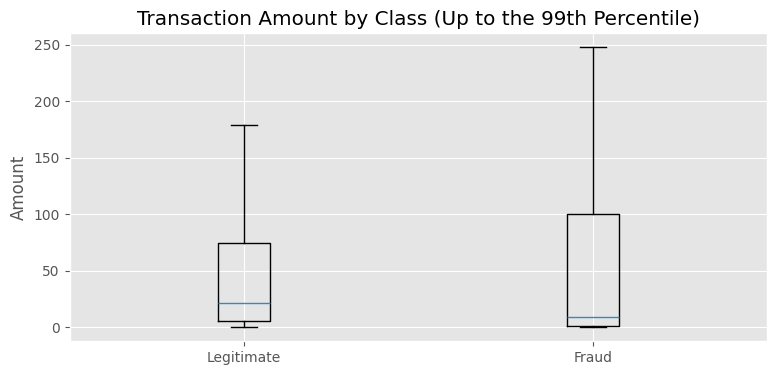

In [111]:
plot_limit = df['Amount'].quantile(0.99)

plt.figure(figsize=(9, 4))
plt.boxplot(
    [
        df.loc[(df['Class'] == 0) & (df['Amount'] <= plot_limit), 'Amount'],
        df.loc[(df['Class'] == 1) & (df['Amount'] <= plot_limit), 'Amount'],
    ],
    tick_labels=['Legitimate', 'Fraud'],
    showfliers=False,
)
plt.title('Transaction Amount by Class (Up to the 99th Percentile)')
plt.ylabel('Amount')
plt.show()

### Features most correlated with the target

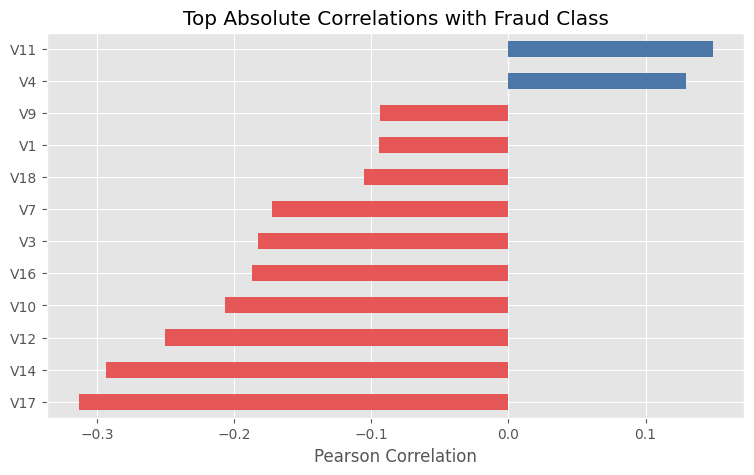

In [112]:
target_correlations = (
    df.corr(numeric_only=True)['Class']
      .drop('Class')
      .sort_values(key=np.abs, ascending=False)
      .head(12)
      .sort_values()
)

colors = ['#E45756' if value < 0 else '#4C78A8' for value in target_correlations]
target_correlations.plot(kind='barh', figsize=(9, 5), color=colors)
plt.title('Top Absolute Correlations with Fraud Class')
plt.xlabel('Pearson Correlation')
plt.show()

## Stage 3: Prepare training and test data

`stratify=y` preserves the rare fraud percentage in both sets. Only `Time` and `Amount` are scaled for Logistic Regression because the `V1`–`V28` variables are already PCA-transformed.

In [113]:
X = df.drop(columns='Class')
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print('Training rows:', X_train.shape[0])
print('Test rows:', X_test.shape[0])
print('Fraud cases in training set:', int(y_train.sum()))
print('Fraud cases in test set:', int(y_test.sum()))

Training rows: 226980
Test rows: 56746
Fraud cases in training set: 378
Fraud cases in test set: 95


## Stage 4: Build and train the models

In [95]:
scale_time_amount = ColumnTransformer(
    transformers=[('scale', StandardScaler(), ['Time', 'Amount'])],
    remainder='passthrough',
)

models = {
    'Dummy Baseline': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': Pipeline(steps=[
        ('preprocessing', scale_time_amount),
        ('classifier', LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=RANDOM_STATE,
        )),
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

trained_models = {}
predictions = {}
probabilities = {}
training_times = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    training_times[name] = time.time() - start
    trained_models[name] = model
    predictions[name] = model.predict(X_test)
    probabilities[name] = model.predict_proba(X_test)[:, 1]
    print(f'{name} training complete: {training_times[name]:.2f} seconds')

Dummy Baseline training complete: 0.06 seconds
Logistic Regression training complete: 8.02 seconds
Random Forest training complete: 187.15 seconds


## Stage 5: Evaluate and compare the models

In [96]:
def evaluate_model(name, y_true, y_pred, y_probability):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_probability),
        'Average Precision': average_precision_score(y_true, y_probability),
        'True Negatives': tn,
        'False Positives': fp,
        'False Negatives': fn,
        'True Positives': tp,
        'Training Time (s)': training_times[name],
    }


results = pd.DataFrame([
    evaluate_model(name, y_test, predictions[name], probabilities[name])
    for name in models
]).set_index('Model')

metric_columns = [
    'Accuracy', 'Precision', 'Recall', 'F1-score',
    'ROC-AUC', 'Average Precision', 'Training Time (s)'
]
results[metric_columns].round(4).sort_values('F1-score', ascending=False)

,Accuracy,Precision,Recall,F1-score,ROC-AUC,Average Precision,Training Time (s)
Model,,,,,,,
Random Forest,0.9994,0.8846,0.7263,0.7977,0.9641,0.7953,187.1547
Logistic Regression,0.9752,0.0562,0.8737,0.1057,0.9658,0.6719,8.0227
Dummy Baseline,0.9983,0.0000,0.0000,0.0000,0.5000,0.0017,0.0588


In [97]:
count_columns = [
    'True Negatives', 'False Positives', 'False Negatives', 'True Positives'
]
results[count_columns].astype(int)

,True Negatives,False Positives,False Negatives,True Positives
Model,,,,
Dummy Baseline,56651,0,95,0
Logistic Regression,55258,1393,12,83
Random Forest,56642,9,26,69


### Confusion matrices

- **False Positive:** A legitimate transaction is incorrectly flagged as fraud.
- **False Negative:** A fraudulent transaction is missed. This error can be especially costly in fraud detection.

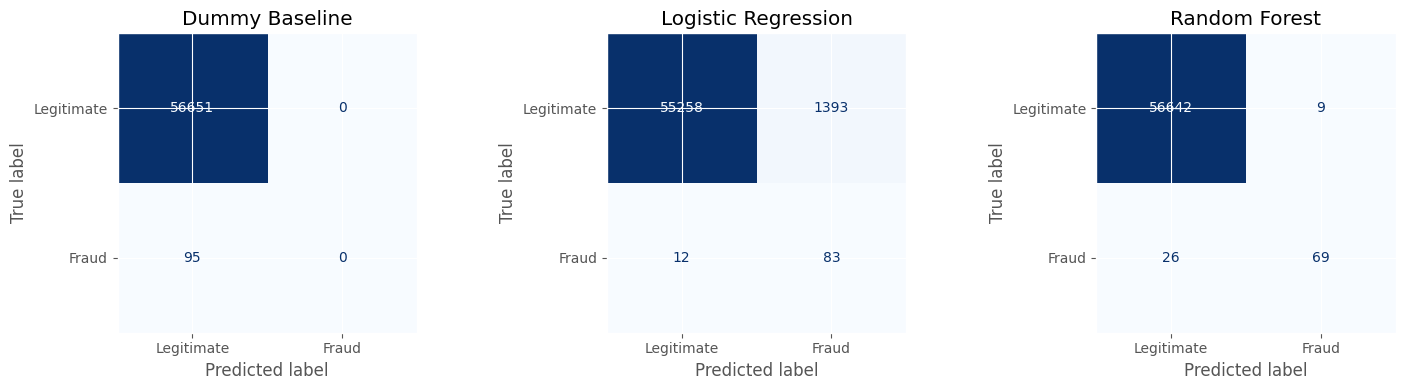

In [98]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name in zip(axes, models):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions[name],
        display_labels=['Legitimate', 'Fraud'],
        cmap='Blues',
        colorbar=False,
        ax=ax,
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

### ROC and Precision–Recall curves

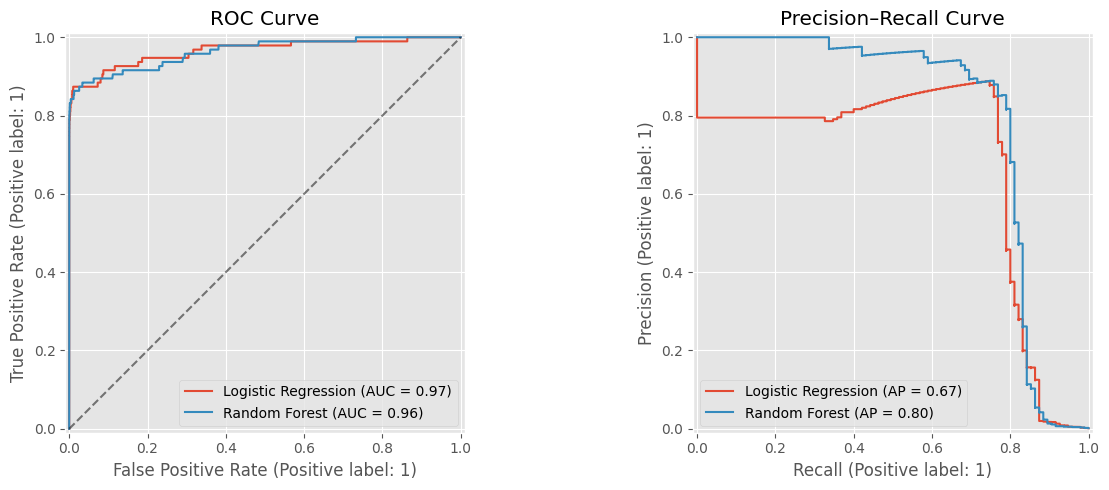

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name in ['Logistic Regression', 'Random Forest']:
    RocCurveDisplay.from_predictions(
        y_test,
        probabilities[name],
        name=name,
        ax=axes[0],
    )
    PrecisionRecallDisplay.from_predictions(
        y_test,
        probabilities[name],
        name=name,
        ax=axes[1],
    )

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title('ROC Curve')
axes[1].set_title('Precision–Recall Curve')
plt.tight_layout()
plt.show()

### Random Forest feature importance

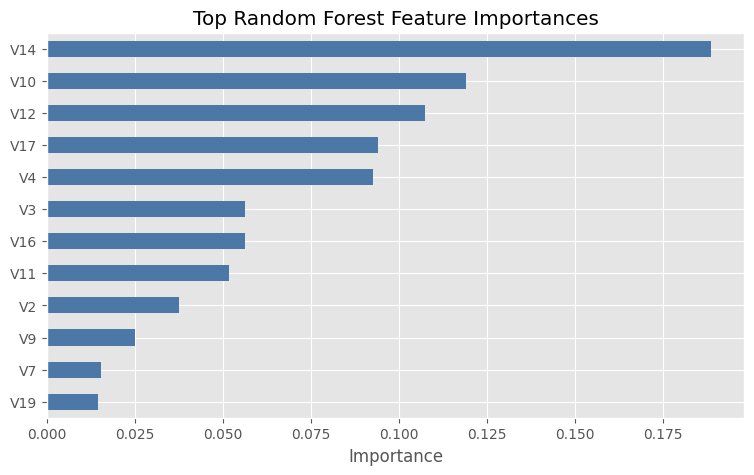

In [100]:
random_forest = trained_models['Random Forest']

feature_importance = (
    pd.Series(random_forest.feature_importances_, index=X.columns)
      .sort_values(ascending=False)
      .head(12)
      .sort_values()
)

feature_importance.plot(kind='barh', figsize=(9, 5), color='#4C78A8')
plt.title('Top Random Forest Feature Importances')
plt.xlabel('Importance')
plt.show()

## Stage 6: Final conclusion

In [101]:
best_model_name = results['F1-score'].idxmax()
best = results.loc[best_model_name]

print('Selected model:', best_model_name)
print(f"Precision: {best['Precision']:.3f}")
print(f"Recall: {best['Recall']:.3f}")
print(f"F1-score: {best['F1-score']:.3f}")
print(f"ROC-AUC: {best['ROC-AUC']:.3f}")
print(f"Average Precision: {best['Average Precision']:.3f}")
print(f"Detected fraud cases: {int(best['True Positives'])}")
print(f"Missed fraud cases: {int(best['False Negatives'])}")
print(f"False alarms: {int(best['False Positives'])}")

Selected model: Random Forest
Precision: 0.885
Recall: 0.726
F1-score: 0.798
ROC-AUC: 0.964
Average Precision: 0.795
Detected fraud cases: 69
Missed fraud cases: 26
False alarms: 9


## Interpretation

The dummy baseline demonstrates why accuracy is not sufficient for this dataset: it labels every transaction as legitimate and fails to detect any fraud.

Logistic Regression generally prioritizes Recall when balanced class weights are used, which helps detect more fraud but may create many false alarms. Random Forest usually provides a stronger balance between Precision and Recall and is selected using F1-score in this notebook.

In a real banking system, the final model and probability threshold should be selected according to the relative cost of missed fraud and false alarms. The anonymized dataset is useful for learning and benchmarking, but production deployment would require current data, monitoring, privacy controls, and regular retraining.